# Detection of Adversarial Examples in Deep Neural Networks using Feature Squeezing

In [1]:
!pip install torch torchvision matplotlib numpy

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


## Load MNIST Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

## Display Sample Images

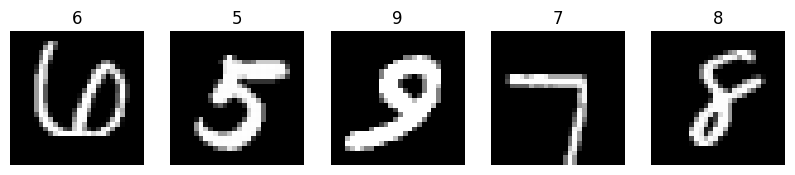

In [4]:
examples = iter(test_loader)
plt.figure(figsize=(10,5))

for i in range(5):
    images, labels = next(examples)
    plt.subplot(1,5,i+1)
    plt.imshow(images[0][0], cmap='gray')
    plt.title(labels[0].item())
    plt.axis('off')
plt.show()

## Define CNN Model

In [5]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Initialize Model

In [6]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

## Train CNN Model

In [7]:
epochs = 3

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/3], Loss: 0.1856
Epoch [2/3], Loss: 0.0530
Epoch [3/3], Loss: 0.0378


## Test Accuracy

In [17]:
correct = 0
total = 0
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 98.82%


## FGSM Attack Function


In [18]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

## Generate Adversarial Example

In [21]:
model.eval()

for image, label in test_loader:
    image = image.to(device)
    label = label.to(device)
    output = model(image)
    _, pred = torch.max(output, 1)
    if pred.item() == label.item():
        example_image = image
        example_label = label
        break

example_image.requires_grad = True
output = model(example_image)
loss = criterion(output, example_label)
model.zero_grad()
loss.backward()
data_grad = example_image.grad.data

epsilon = 0.15

adv_image = fgsm_attack(
    example_image,
    epsilon,
    data_grad
)

## Compare Predictions

In [22]:
original_output = model(example_image)
_, original_pred = torch.max(original_output, 1)
adversarial_output = model(adv_image)
_, adversarial_pred = torch.max(adversarial_output, 1)
print("Original Prediction:", original_pred.item())
print("Adversarial Prediction:", adversarial_pred.item())

Original Prediction: 4
Adversarial Prediction: 9


## Visualize Original vs Adversarial

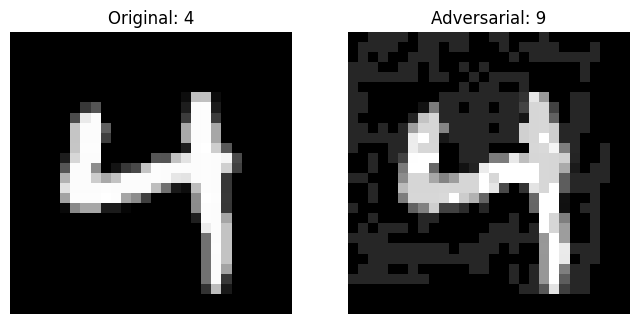

In [23]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(example_image.cpu().detach().numpy()[0][0], cmap='gray')
plt.title(f"Original: {original_pred.item()}")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(adv_image.cpu().detach().numpy()[0][0], cmap='gray')
plt.title(f"Adversarial: {adversarial_pred.item()}")
plt.axis('off')
plt.show()

## Feature Squeezing Function

In [24]:
def feature_squeeze(image, bit_depth=2):
    levels = 2 ** bit_depth
    squeezed = torch.floor(image * levels) / levels
    return squeezed

## Apply Feature Squeezing

In [25]:
squeezed_image = feature_squeeze(adv_image)
squeezed_output = model(squeezed_image)
_, squeezed_pred = torch.max(squeezed_output, 1)
print("Prediction After Squeezing:", squeezed_pred.item())

Prediction After Squeezing: 4


## Visualize Final Results

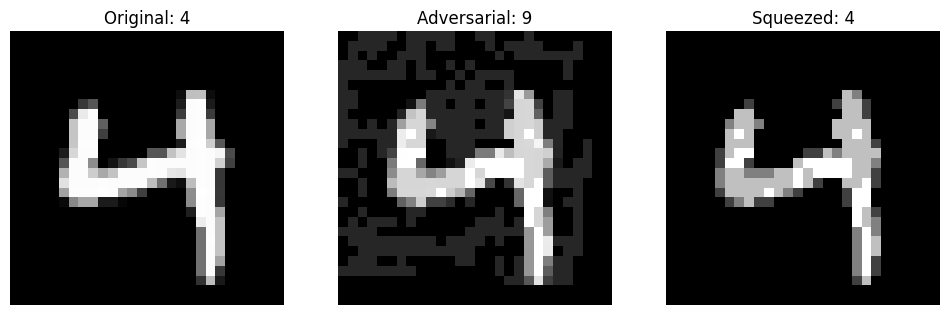

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(example_image.cpu().detach().numpy()[0][0], cmap='gray')
plt.title(f"Original: {original_pred.item()}")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(adv_image.cpu().detach().numpy()[0][0], cmap='gray')
plt.title(f"Adversarial: {adversarial_pred.item()}")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(squeezed_image.cpu().detach().numpy()[0][0], cmap='gray')
plt.title(f"Squeezed: {squeezed_pred.item()}")
plt.axis('off')
plt.show()

## Detection Logic

In [27]:
if adversarial_pred.item() != squeezed_pred.item():
    print("Adversarial Attack Detected")
else:
    print("Image Appears Safe")

Adversarial Attack Detected
